# Frozen-model TCGA downstream benchmark

This notebook is the human-readable record for five-cohort cancer classification and pan-cancer overall-survival prediction. Our 45.6M FM and both BulkFormer models are frozen; identical PCA-128 downstream probes and five patient-level 80/20 splits are used. Published BulkRNABert values are included only as clearly separated literature references because they were generated on the authors' splits.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE = Path.cwd() if Path.cwd().name == 'tcga_downstream' else Path('benchmarks/tcga_downstream')
RESULTS = HERE / 'results'
FIGURES = RESULTS / 'figures'; FIGURES.mkdir(exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Cohorts and endpoints

One deterministic primary-tumor aliquot is retained per TCGA patient. Classification combines GBM and LGG as GBMLGG. Survival uses curated PanCanAtlas overall-survival time and event labels.

In [2]:
cohort = pd.read_parquet(RESULTS / 'cohort_manifest.parquet')
cohort_summary = pd.read_parquet(RESULTS / 'cohort_summary.parquet')
display(pd.DataFrame([{'Primary-tumor patients': len(cohort),
    'Classification patients': int(cohort.classification_usable.sum()),
    'Survival patients': int(cohort.survival_usable.sum()),
    'Pan-cancer cohorts': cohort.cohort.nunique(),
    'Survival events': int(cohort.loc[cohort.survival_usable, 'event'].sum())}]).style.hide(axis='index'))
display(cohort_summary.style.format({'events': '{:.0f}'}).hide(axis='index'))

Primary-tumor patients,Classification patients,Survival patients,Pan-cancer cohorts,Survival events
9816,3227,9668,32,2774


cohort,patients,survival_usable,events,classification_usable
ACC,79,79,28,0
BLCA,408,406,179,408
BRCA,1093,1079,151,1093
CESC,304,291,71,0
CHOL,36,36,18,0
COAD,458,439,102,0
DLBC,48,47,9,0
ESCA,184,184,77,0
GBM,155,154,122,155
HNSC,502,501,217,0


## 2. Five-cohort cancer classification

The primary comparison uses each complete frozen native embedding with the BulkRNABert-style classification MLP `[256, 128]`. The raw baseline uses all 25,150 TCGA expression columns directly. Identical patient-level train/validation/test splits, optimization, early stopping, and five seeds are used. PCA-128 linear probes remain available as secondary controls in the complete tables.

Model,native_features,probe,splits,macro_f1_mean,macro_f1_sd,weighted_f1_mean,weighted_f1_sd,balanced_accuracy_mean,balanced_accuracy_sd
BulkFormer-147M,643,native_mlp_256_128,5,0.9837,0.0066,0.9861,0.0055,0.9833,0.0065
BulkFormer-50M,259,native_mlp_256_128,5,0.9751,0.0073,0.9796,0.0061,0.9750,0.0088
Full raw expression,25150,native_mlp_256_128,5,0.9886,0.0046,0.9904,0.0040,0.9894,0.0046
Our FM (45.6M),512,native_mlp_256_128,5,0.9796,0.0068,0.9830,0.0057,0.9794,0.0079


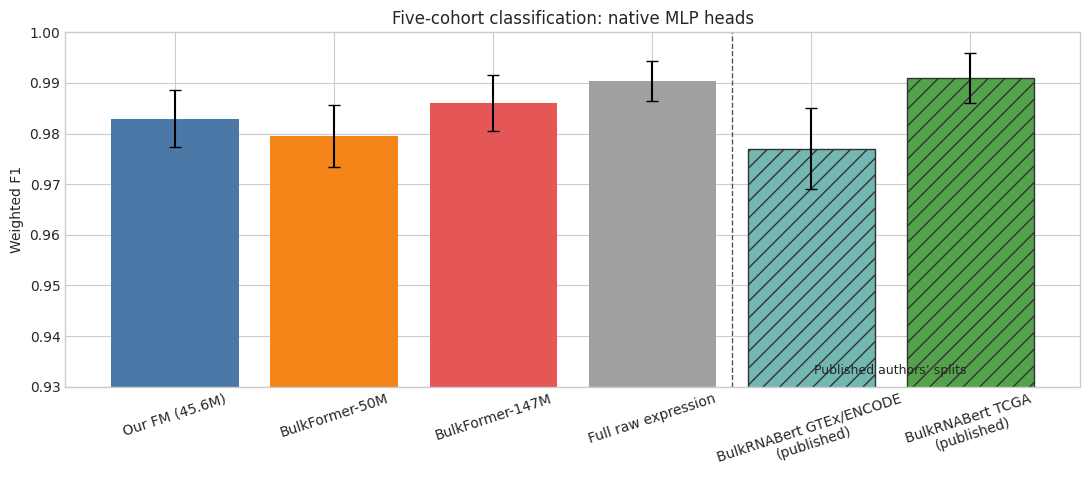

In [3]:
classification_linear = pd.read_parquet(RESULTS / 'classification_summary.parquet')
classification = pd.read_parquet(RESULTS / 'classification_mlp_summary.parquet')
labels = {'ours_45.6m': 'Our FM (45.6M)', 'bulkformer_50m': 'BulkFormer-50M',
          'bulkformer_147m': 'BulkFormer-147M', 'full_expression_25150': 'Full raw expression',
          'raw_expression': 'Raw expression PCA control'}
classification['Model'] = classification.representation.map(labels)
display(classification[['Model','native_features','probe','splits','macro_f1_mean','macro_f1_sd',
    'weighted_f1_mean','weighted_f1_sd','balanced_accuracy_mean','balanced_accuracy_sd']]
    .style.format({c: '{:.4f}' for c in classification.columns if c.endswith(('_mean','_sd'))}).hide(axis='index'))
primary_order = ['Our FM (45.6M)','BulkFormer-50M','BulkFormer-147M','Full raw expression']
plot = classification.set_index('Model').loc[primary_order]
published = pd.read_parquet(RESULTS / 'published_reference_results.parquet')
refs = published[(published.task.eq('five_cohort_classification')) & published.metric.eq('weighted_f1') &
                 published.method.str.startswith('BulkRNABert')].copy()
names = list(plot.index) + ['BulkRNABert GTEx/ENCODE\n(published)', 'BulkRNABert TCGA\n(published)']
values = list(plot.weighted_f1_mean) + [refs.loc[refs.method.str.contains('GTEx'), 'mean'].iloc[0],
    refs.loc[refs.method.eq('BulkRNABert(TCGA)+SVM'), 'mean'].iloc[0]]
errors = list(plot.weighted_f1_sd) + [refs.loc[refs.method.str.contains('GTEx'), 'sd'].iloc[0],
    refs.loc[refs.method.eq('BulkRNABert(TCGA)+SVM'), 'sd'].iloc[0]]
fig, ax = plt.subplots(figsize=(11,5)); bars = ax.bar(names, values, yerr=errors, capsize=4,
    color=['#4C78A8','#F58518','#E45756','#A0A0A0','#72B7B2','#54A24B'])
for bar in bars[-2:]: bar.set_hatch('//'); bar.set_edgecolor('#333333')
ax.axvline(3.5, color='#555555', linestyle='--', linewidth=1)
ax.text(4.5, .932, 'Published authors’ splits', ha='center', va='bottom', fontsize=9)
ax.set(ylabel='Weighted F1', title='Five-cohort classification: native MLP heads', ylim=(.93,1.0)); ax.tick_params(axis='x',rotation=18)
fig.tight_layout(); fig.savefig(FIGURES/'classification_weighted_f1.png',dpi=250,bbox_inches='tight'); plt.show()

## 3. Pan-cancer overall survival

The primary comparison uses each complete frozen native embedding with the BulkRNABert-style survival MLP `[512, 256]`, trained using Cox partial-likelihood loss. The raw baseline uses all 25,150 TCGA expression columns directly. Pooled C-index measures global ranking; weighted and macro C-index summarize within-cohort discrimination. PCA-128 Cox probes remain secondary controls.

Model,native_features,probe,splits,c_index_mean,c_index_sd,weighted_c_index_mean,weighted_c_index_sd,macro_c_index_mean,macro_c_index_sd
BulkFormer-147M,643,native_mlp_512_256_cox,5,0.7620,0.0120,0.6320,0.0202,0.6242,0.0225
BulkFormer-50M,259,native_mlp_512_256_cox,5,0.7588,0.0113,0.6168,0.0329,0.6119,0.0217
Full raw expression,25150,native_mlp_512_256_cox,5,0.7610,0.0146,0.6145,0.0136,0.6119,0.0190
Our FM (45.6M),512,native_mlp_512_256_cox,5,0.7597,0.0111,0.5995,0.0260,0.5963,0.0350


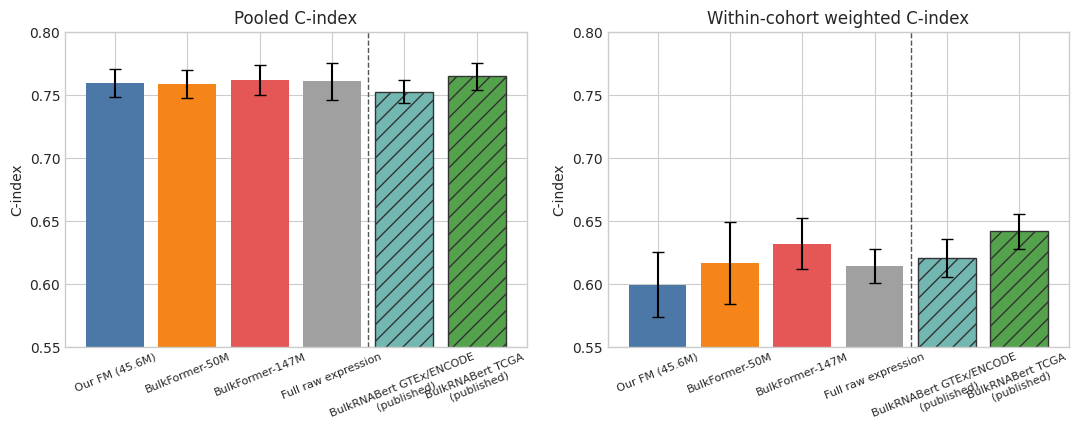

In [4]:
survival_linear = pd.read_parquet(RESULTS / 'survival_summary.parquet')
survival = pd.read_parquet(RESULTS / 'survival_mlp_summary.parquet')
survival['Model'] = survival.representation.map(labels)
display(survival[['Model','native_features','probe','splits','c_index_mean','c_index_sd','weighted_c_index_mean',
    'weighted_c_index_sd','macro_c_index_mean','macro_c_index_sd']]
    .style.format({c: '{:.4f}' for c in survival.columns if c.endswith(('_mean','_sd'))}).hide(axis='index'))
plot = survival.set_index('Model').loc[primary_order]
published_survival = pd.read_parquet(RESULTS / 'published_reference_results.parquet')
published_survival = published_survival[published_survival.task.eq('pan_cancer_survival') &
    published_survival.method.str.startswith('BulkRNABert')]
reference_names = ['BulkRNABert GTEx/ENCODE\n(published)', 'BulkRNABert TCGA\n(published)']
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
for ax, metric, title in [(axes[0],'c_index','Pooled C-index'),(axes[1],'weighted_c_index','Within-cohort weighted C-index')]:
    refs = published_survival[published_survival.metric.eq(metric)].set_index('method')
    names = list(plot.index) + reference_names
    values = list(plot[f'{metric}_mean']) + [refs.loc['BulkRNABert(GTEx ENCODE)','mean'], refs.loc['BulkRNABert(TCGA)','mean']]
    errors = list(plot[f'{metric}_sd']) + [refs.loc['BulkRNABert(GTEx ENCODE)','sd'], refs.loc['BulkRNABert(TCGA)','sd']]
    bars = ax.bar(names, values, yerr=errors, capsize=4,
           color=['#4C78A8','#F58518','#E45756','#A0A0A0','#72B7B2','#54A24B'])
    for bar in bars[-2:]: bar.set_hatch('//'); bar.set_edgecolor('#333333')
    ax.axvline(3.5, color='#555555', linestyle='--', linewidth=1)
    ax.set(ylabel='C-index',title=title,ylim=(.55,.80)); ax.tick_params(axis='x',rotation=22, labelsize=8)
fig.tight_layout(); fig.savefig(FIGURES/'survival_c_index.png',dpi=250,bbox_inches='tight'); plt.show()

## 3.1 Mean pooling versus learned attention pooling

This exploratory one-seed ablation keeps the 45.6M FM completely frozen and changes only aggregation of its 15,165 contextual 512-D gene tokens. Mean pooling is compared with a learned content-attention weight over every gene on the identical seed-0 patient split and downstream MLP settings. FM inputs are `log1p(TPM)`, matching checkpoint `r7hnr92k`; the full-expression control elsewhere uses `log1p(CPM)`. Because attention was run once, no attention SD is reported.

**Result.** Attention pooling did not improve seed-0 classification (weighted F1 0.9735 versus 0.9737) and reduced survival discrimination: pooled C-index 0.7529 versus 0.7607, weighted within-cancer C-index 0.5836 versus 0.6109, and macro within-cancer C-index 0.5932 versus 0.6096. This exploratory result does not support mean pooling as the principal limitation, so additional attention seeds were not run.

Classification: frozen FM pooling ablation


seed,pooling,macro_f1,weighted_f1,balanced_accuracy
0,mean,0.968650,0.973679,0.967240
0,learned_attention,0.966247,0.973470,0.963006


Survival: frozen FM pooling ablation


seed,pooling,c_index,weighted_c_index,macro_c_index
0,mean,0.760718,0.610929,0.609642
0,learned_attention,0.752929,0.583627,0.593173


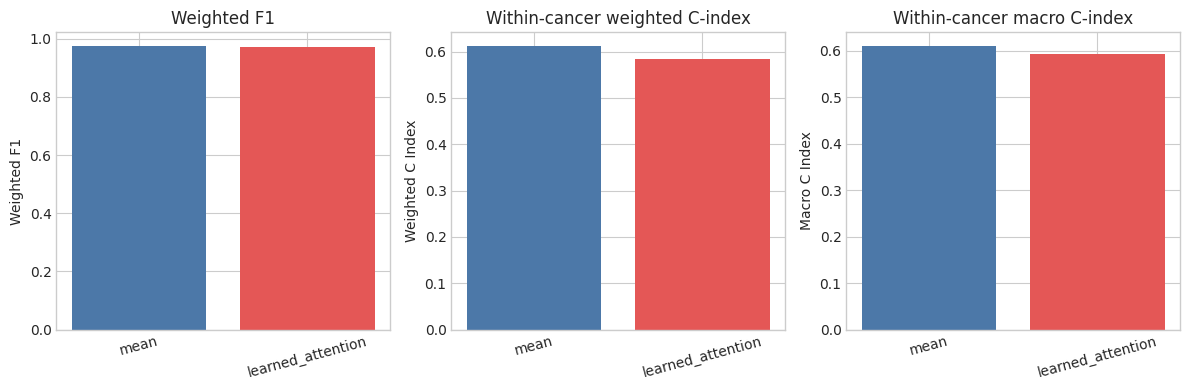

In [5]:
pooling_files = {
    'Classification': RESULTS/'ours_pooling_classification_seed0.parquet',
    'Survival': RESULTS/'ours_pooling_survival_seed0.parquet'}
if not all(path.exists() for path in pooling_files.values()):
    print('Attention-pooling results are not complete. Run pipeline/run_attention_pooling.py; the runner is resumable by seed.')
else:
    pooling_classification = pd.read_parquet(pooling_files['Classification'])
    pooling_survival = pd.read_parquet(pooling_files['Survival'])
    print('Classification: frozen FM pooling ablation')
    display(pooling_classification.style.format({c:'{:.4f}' for c in pooling_classification if c.endswith(('_mean','_sd'))}).hide(axis='index'))
    print('Survival: frozen FM pooling ablation')
    display(pooling_survival.style.format({c:'{:.4f}' for c in pooling_survival if c.endswith(('_mean','_sd'))}).hide(axis='index'))
    fig, axes = plt.subplots(1,3,figsize=(12,4))
    panels = [(pooling_classification,'weighted_f1','Weighted F1'),
              (pooling_survival,'weighted_c_index','Within-cancer weighted C-index'),
              (pooling_survival,'macro_c_index','Within-cancer macro C-index')]
    for ax,(frame,metric,title) in zip(axes,panels):
        frame = frame.set_index('pooling').reindex(['mean','learned_attention']).dropna(how='all')
        ax.bar(frame.index,frame[metric],color=['#4C78A8','#E45756'])
        ax.set(title=title,ylabel=metric.replace('_',' ').title()); ax.tick_params(axis='x',rotation=15)
    fig.tight_layout(); fig.savefig(FIGURES/'ours_mean_vs_attention_pooling.png',dpi=250,bbox_inches='tight'); plt.show()

## 4. Published reference values

These values are transcribed from the BulkRNABert paper. They provide context only: their preprocessing, splits, heads, and pretraining exposure differ from the common local benchmark above.

In [6]:
published = pd.read_parquet(RESULTS / 'published_reference_results.parquet')
display(published.style.format({'mean':'{:.3f}','sd':'{:.3f}'}).hide(axis='index'))

task,method,metric,mean,sd
five_cohort_classification,NMF-128+SVM (published),weighted_f1,0.898,0.018
five_cohort_classification,PCA-256+SVM (published),weighted_f1,0.968,0.010
five_cohort_classification,BulkRNABert(GTEx ENCODE)+SVM,weighted_f1,0.977,0.008
five_cohort_classification,BulkRNABert(TCGA)+SVM,weighted_f1,0.991,0.005
pan_cancer_classification,BulkRNABert(GTEx ENCODE)+SVM,macro_f1,0.887,0.005
pan_cancer_classification,BulkRNABert(GTEx ENCODE)+SVM,weighted_f1,0.918,0.005
pan_cancer_survival,BulkRNABert(GTEx ENCODE),c_index,0.753,0.009
pan_cancer_survival,BulkRNABert(GTEx ENCODE),weighted_c_index,0.621,0.015
pan_cancer_survival,BulkRNABert(TCGA),c_index,0.765,0.011
pan_cancer_survival,BulkRNABert(TCGA),weighted_c_index,0.642,0.014


### 4.1 Complete comparison tables

These tables place all locally evaluated results and applicable published references in one view. `Local common splits` and `Published authors’ splits` must be interpreted separately; differences between those groups are descriptive rather than paired statistical comparisons.

In [7]:
local_classification = classification.assign(
    source='Local native-head splits', method=classification['Model'], input_features=classification['native_features'],
    task='five_cohort_classification')[['task','source','method','probe','splits','input_features',
        'macro_f1_mean','macro_f1_sd','weighted_f1_mean','weighted_f1_sd',
        'balanced_accuracy_mean','balanced_accuracy_sd']]
published_classification = published[published.task.eq('five_cohort_classification')].copy()
published_classification = published_classification.pivot_table(
    index=['task','method'], columns='metric', values=['mean','sd'], aggfunc='first')
published_classification.columns = [f'{metric}_{stat}' for stat, metric in published_classification.columns]
published_classification = published_classification.reset_index().assign(
    source='Published authors’ splits', probe='As published', splits=5, input_features=np.nan)
linear_classification = classification_linear.assign(
    Model=classification_linear.representation.map(labels), source='Local PCA-128 controls',
    method=lambda frame: frame.Model, task='five_cohort_classification', input_features=128)[
    ['task','source','method','probe','splits','input_features','macro_f1_mean','macro_f1_sd',
     'weighted_f1_mean','weighted_f1_sd','balanced_accuracy_mean','balanced_accuracy_sd']]
for column in local_classification.columns:
    if column not in published_classification: published_classification[column] = np.nan
classification_all = pd.concat([local_classification, linear_classification,
    published_classification[local_classification.columns]], ignore_index=True)
classification_all.to_parquet(RESULTS/'classification_all_results.parquet', index=False)
classification_all.to_csv(RESULTS/'classification_all_results.csv', index=False)
print('All five-cohort classification results')
display(classification_all.style.format({c:'{:.4f}' for c in classification_all if c.endswith(('_mean','_sd'))},
    na_rep='—').hide(axis='index'))

local_survival = survival.assign(source='Local native-head splits', method=survival['Model'],
    input_features=survival['native_features'], task='pan_cancer_survival')[['task','source','method','probe','splits','input_features','c_index_mean','c_index_sd',
        'weighted_c_index_mean','weighted_c_index_sd','macro_c_index_mean','macro_c_index_sd']]
published_survival_all = published[published.task.eq('pan_cancer_survival')].copy()
published_survival_all = published_survival_all.pivot_table(
    index=['task','method'], columns='metric', values=['mean','sd'], aggfunc='first')
published_survival_all.columns = [f'{metric}_{stat}' for stat, metric in published_survival_all.columns]
published_survival_all = published_survival_all.reset_index().assign(
    source='Published authors’ splits', probe='As published', splits=5, input_features=np.nan)
linear_survival = survival_linear.assign(Model=survival_linear.representation.map(labels),
    source='Local PCA-128 controls', method=lambda frame: frame.Model, task='pan_cancer_survival',
    input_features=128)[['task','source','method','probe','splits','input_features','c_index_mean','c_index_sd',
    'weighted_c_index_mean','weighted_c_index_sd','macro_c_index_mean','macro_c_index_sd']]
for column in local_survival.columns:
    if column not in published_survival_all: published_survival_all[column] = np.nan
survival_all = pd.concat([local_survival, linear_survival,
    published_survival_all[local_survival.columns]], ignore_index=True)
survival_all.to_parquet(RESULTS/'survival_all_results.parquet', index=False)
survival_all.to_csv(RESULTS/'survival_all_results.csv', index=False)
print('All pan-cancer survival results')
display(survival_all.style.format({c:'{:.4f}' for c in survival_all if c.endswith(('_mean','_sd'))},
    na_rep='—').hide(axis='index'))

All five-cohort classification results


task,source,method,probe,splits,input_features,macro_f1_mean,macro_f1_sd,weighted_f1_mean,weighted_f1_sd,balanced_accuracy_mean,balanced_accuracy_sd
five_cohort_classification,Local native-head splits,BulkFormer-147M,native_mlp_256_128,5,643.000000,0.9837,0.0066,0.9861,0.0055,0.9833,0.0065
five_cohort_classification,Local native-head splits,BulkFormer-50M,native_mlp_256_128,5,259.000000,0.9751,0.0073,0.9796,0.0061,0.9750,0.0088
five_cohort_classification,Local native-head splits,Full raw expression,native_mlp_256_128,5,25150.000000,0.9886,0.0046,0.9904,0.0040,0.9894,0.0046
five_cohort_classification,Local native-head splits,Our FM (45.6M),native_mlp_256_128,5,512.000000,0.9796,0.0068,0.9830,0.0057,0.9794,0.0079
five_cohort_classification,Local PCA-128 controls,BulkFormer-147M,linear_svm,5,128.000000,0.9883,0.0066,0.9904,0.0053,0.9883,0.0070
five_cohort_classification,Local PCA-128 controls,BulkFormer-147M,logistic_regression,5,128.000000,0.9849,0.0063,0.9873,0.0054,0.9848,0.0063
five_cohort_classification,Local PCA-128 controls,BulkFormer-50M,linear_svm,5,128.000000,0.9776,0.0048,0.9823,0.0036,0.9772,0.0055
five_cohort_classification,Local PCA-128 controls,BulkFormer-50M,logistic_regression,5,128.000000,0.9760,0.0078,0.9805,0.0062,0.9763,0.0090
five_cohort_classification,Local PCA-128 controls,Our FM (45.6M),linear_svm,5,128.000000,0.9877,0.0043,0.9895,0.0037,0.9879,0.0052
five_cohort_classification,Local PCA-128 controls,Our FM (45.6M),logistic_regression,5,128.000000,0.9846,0.0085,0.9870,0.0070,0.9850,0.0091


All pan-cancer survival results


task,source,method,probe,splits,input_features,c_index_mean,c_index_sd,weighted_c_index_mean,weighted_c_index_sd,macro_c_index_mean,macro_c_index_sd
pan_cancer_survival,Local native-head splits,BulkFormer-147M,native_mlp_512_256_cox,5,643.000000,0.7620,0.0120,0.6320,0.0202,0.6242,0.0225
pan_cancer_survival,Local native-head splits,BulkFormer-50M,native_mlp_512_256_cox,5,259.000000,0.7588,0.0113,0.6168,0.0329,0.6119,0.0217
pan_cancer_survival,Local native-head splits,Full raw expression,native_mlp_512_256_cox,5,25150.000000,0.7610,0.0146,0.6145,0.0136,0.6119,0.0190
pan_cancer_survival,Local native-head splits,Our FM (45.6M),native_mlp_512_256_cox,5,512.000000,0.7597,0.0111,0.5995,0.0260,0.5963,0.0350
pan_cancer_survival,Local PCA-128 controls,BulkFormer-147M,pca128_cox,5,128.000000,0.7538,0.0119,0.6177,0.0153,0.6140,0.0238
pan_cancer_survival,Local PCA-128 controls,BulkFormer-50M,pca128_cox,5,128.000000,0.7512,0.0075,0.6228,0.0209,0.6101,0.0223
pan_cancer_survival,Local PCA-128 controls,Our FM (45.6M),pca128_cox,5,128.000000,0.7578,0.0138,0.6237,0.0233,0.6278,0.0226
pan_cancer_survival,Local PCA-128 controls,Raw expression PCA control,pca128_cox,5,128.000000,0.7647,0.0132,0.6262,0.0101,0.6211,0.0130
pan_cancer_survival,Published authors’ splits,BulkRNABert(GTEx ENCODE),As published,5,—,0.7530,0.0090,0.6210,0.0150,—,—
pan_cancer_survival,Published authors’ splits,BulkRNABert(TCGA),As published,5,—,0.7650,0.0110,0.6420,0.0140,—,—


## 5. Conservative interpretation

With native vocabularies and complete frozen representations, all models distinguish the five cancer groups well. Full 25,150-feature expression is strongest (weighted F1 0.9904), followed by BulkFormer-147M (0.9861), our 45.6M FM (0.9830), and BulkFormer-50M (0.9796). Thus, despite its smaller 15,165-gene vocabulary, our model remains competitive without forcing competitors into that vocabulary. Pooled pan-cancer survival discrimination is nearly tied (mean C-index 0.759–0.762), whereas BulkFormer-147M is strongest on weighted and macro within-cohort C-index; our model is lower and more variable on those endpoints. The PCA-128 linear results are secondary controls, not the primary comparison. These findings support useful transferable representations but not a universal advantage over full expression or larger models. Published values use the authors' own splits and training procedures, and pretraining exposure is not uniform—particularly for TCGA-derived models—so this benchmark measures downstream utility rather than strict unseen-sample generalization.